In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("park-boston-monthly-transactions-by-zone-2015.csv")

# View first rows
df.head()

,#,Zone Name,January,February,March,April,May,June,July,August,September,October,November,December,GT by Zone
0,478,North Charles between Boylston and Beacon,147.0,456.0,602.0,719.0,714.0,841.0,316.0,NaN,NaN,NaN,NaN,NaN,3795.0
1,888,East Newbury between Arlington and Berkeley,138.0,289.0,600.0,640.0,632.0,703.0,306.0,NaN,NaN,NaN,NaN,NaN,3308.0
2,561,South Newbury between Mass and Charlesgate E,0.0,0.0,4.0,540.0,825.0,1289.0,477.0,NaN,NaN,NaN,NaN,NaN,3135.0
3,892,East Newbury between Clarendon and Dartmouth,119.0,340.0,457.0,502.0,558.0,773.0,322.0,NaN,NaN,NaN,NaN,NaN,3071.0
4,924,North Boylston between Clarendon and Berkeley,104.0,248.0,470.0,529.0,605.0,687.0,298.0,NaN,NaN,NaN,NaN,NaN,2941.0


In [6]:

# Shape
print(df.shape)





(572, 15)


In [3]:
# Columns
print(df.columns)

Index(['#', 'Zone Name', 'January ', 'February ', 'March ', 'April ', 'May ',
       'June ', 'July', 'August', 'September', 'October', 'November',
       'December', 'GT by Zone'],
      dtype='str')


In [4]:
# Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   #           572 non-null    int64  
 1   Zone Name   572 non-null    str    
 2   January     568 non-null    float64
 3   February    567 non-null    float64
 4   March       567 non-null    float64
 5   April       567 non-null    float64
 6   May         568 non-null    float64
 7   June        568 non-null    float64
 8   July        557 non-null    float64
 9   August      0 non-null      float64
 10  September   0 non-null      float64
 11  October     0 non-null      float64
 12  November    0 non-null      float64
 13  December    0 non-null      float64
 14  GT by Zone  568 non-null    float64
dtypes: float64(13), int64(1), str(1)
memory usage: 67.2 KB


In [5]:
# Summary stats
df.describe()

,#,January,February,March,April,May,June,July,August,September,October,November,December,GT by Zone
count,572.000000,568.000000,567.000000,567.000000,567.000000,568.000000,568.000000,557.000000,0.0,0.0,0.0,0.0,0.0,568.000000
mean,473.276224,3.758803,8.328042,17.176367,57.093474,82.378521,138.713028,63.736086,NaN,NaN,NaN,NaN,NaN,369.795775
std,269.282345,17.784322,44.236415,80.025751,127.269254,130.695208,164.515473,63.310446,NaN,NaN,NaN,NaN,NaN,544.309728
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,237.750000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,18.000000,NaN,NaN,NaN,NaN,NaN,57.000000
50%,501.500000,0.000000,0.000000,0.000000,0.000000,1.000000,80.000000,47.000000,NaN,NaN,NaN,NaN,NaN,146.000000
75%,658.250000,0.000000,0.000000,0.000000,57.500000,132.000000,191.000000,84.000000,NaN,NaN,NaN,NaN,NaN,485.250000
max,943.000000,147.000000,456.000000,602.000000,1399.000000,825.000000,1289.000000,477.000000,NaN,NaN,NaN,NaN,NaN,3795.000000


In [7]:
# Remove extra spaces
df.columns = df.columns.str.strip()

print(df.columns)

Index(['#', 'Zone Name', 'January', 'February', 'March', 'April', 'May',
       'June', 'July', 'August', 'September', 'October', 'November',
       'December', 'GT by Zone'],
      dtype='str')


In [8]:
# Check missing
df.isnull().sum()

# Fill missing with 0
df = df.fillna(0)

In [9]:
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

In [10]:
monthly_totals = df[months].sum()

print(monthly_totals)

January       2135.0
February      4722.0
March         9739.0
April        32372.0
May          46791.0
June         78789.0
July         35501.0
August           0.0
September        0.0
October          0.0
November         0.0
December         0.0
dtype: float64


In [11]:
top_zones = df.sort_values(by="GT by Zone", ascending=False).head(10)

print(top_zones[["Zone Name", "GT by Zone"]])

                                       Zone Name  GT by Zone
0      North Charles between Boylston and Beacon      3795.0
1    East Newbury between Arlington and Berkeley      3308.0
2   South Newbury between Mass and Charlesgate E      3135.0
3   East Newbury between Clarendon and Dartmouth      3071.0
4  North Boylston between Clarendon and Berkeley      2941.0
5    West Newbury between Berkeley and Clarendon      2901.0
6    West Newbury between Arlington and Berkeley      2828.0
7    East Newbury between Berkeley and Clarendon      2762.0
8  North Boylston between Arlington and Charles       2724.0
9  South Boylston between Berkeley and Arlington      2683.0


In [12]:
df["Total"] = df[months].sum(axis=1)

In [13]:
seasons = {
    "Winter": ["December","January","February"],
    "Spring": ["March","April","May"],
    "Summer": ["June","July","August"],
    "Fall": ["September","October","November"]
}

season_totals = {}
for season, months_list in seasons.items():
    season_totals[season] = df[months_list].sum().sum()

print(season_totals)

{'Winter': np.float64(6857.0), 'Spring': np.float64(88902.0), 'Summer': np.float64(114290.0), 'Fall': np.float64(0.0)}


In [14]:
print(df.columns.tolist())

['#', 'Zone Name', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'GT by Zone', 'Total']


In [15]:
df[["September","October","November"]].sum()

September    0.0
October      0.0
November     0.0
dtype: float64

In [16]:
seasons = {
    "Winter": ["January","February"],
    "Spring": ["March","April","May"],
    "Summer": ["June","July","August"]
}

season_totals = {
    season: df[months].sum().sum()
    for season, months in seasons.items()
}

print(season_totals)

{'Winter': np.float64(6857.0), 'Spring': np.float64(88902.0), 'Summer': np.float64(114290.0)}


In [17]:
season_avg = {
    "Winter": df[["January","February"]].mean().mean(),
    "Spring": df[["March","April","May"]].mean().mean(),
    "Summer": df[["June","July","August"]].mean().mean()
}

print(season_avg)

{'Winter': np.float64(5.993881118881118), 'Spring': np.float64(51.8076923076923), 'Summer': np.float64(66.6025641025641)}


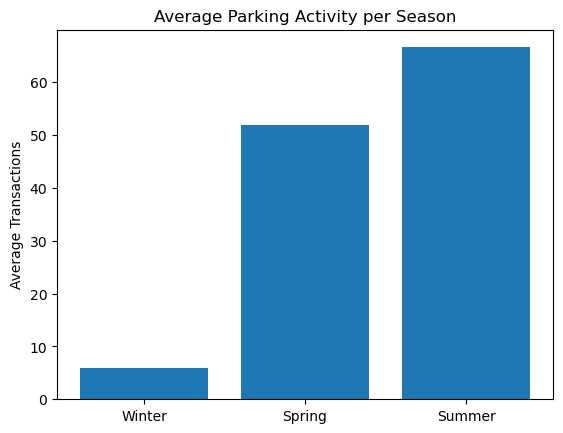

In [18]:
import matplotlib.pyplot as plt

plt.bar(season_avg.keys(), season_avg.values())
plt.title("Average Parking Activity per Season")
plt.ylabel("Average Transactions")
plt.show()

In [19]:
top_zones = df.sort_values(by="GT by Zone", ascending=False).head(10)

top_zones[["Zone Name", "GT by Zone"]]

,Zone Name,GT by Zone
0,North Charles between Boylston and Beacon,3795.0
1,East Newbury between Arlington and Berkeley,3308.0
2,South Newbury between Mass and Charlesgate E,3135.0
3,East Newbury between Clarendon and Dartmouth,3071.0
4,North Boylston between Clarendon and Berkeley,2941.0
5,West Newbury between Berkeley and Clarendon,2901.0
6,West Newbury between Arlington and Berkeley,2828.0
7,East Newbury between Berkeley and Clarendon,2762.0
8,North Boylston between Arlington and Charles,2724.0
9,South Boylston between Berkeley and Arlington,2683.0


In [20]:
bottom_zones = df.sort_values(by="GT by Zone").head(10)

bottom_zones[["Zone Name", "GT by Zone"]]

,Zone Name,GT by Zone
571,North Cummington between Blanford and Hinsda,0.0
567,North St between Mass and Symphony,0.0
570,South Brookline between Park Dr and Kilmarnoc,0.0
569,South Westland between Henenway and Mass.,0.0
568,South Kneeland between Monsignor Shea Road and,0.0
565,South Commonwealth between Hinsdale and Bland,1.0
543,South Summer between Melcher and West Side,1.0
544,East Cambridge between Court and Sudbury,1.0
545,West Trinity between Garage and Stuart,1.0
546,West Arlington between Beacon and Marlborough,1.0
